# Predicting House Prices with Linear Regression

**Objective:** Build and evaluate a linear regression model that predicts house prices from features such as area, location, number of rooms, and age — covering the full workflow from data cleaning to model interpretation.

**Dataset:** `house_prices.csv` — 2,000 residential property records with structural features (area, bedrooms, bathrooms, age, lot size, garage, stories), location (neighborhood), and amenity/context features (pool, school rating, distance to city center, renovation status).

**Tech stack:** Python, pandas, scikit-learn, matplotlib, seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42


## 1. Load Dataset and Perform EDA

In [2]:
df = pd.read_csv("house_prices.csv")
print("Shape:", df.shape)
df.head()


Shape: (2000, 14)


,Price,AreaSqFt,Bedrooms,Bathrooms,AgeYears,LotSizeSqFt,GarageSpaces,Stories,Neighborhood,HouseStyle,HasPool,DistanceToCityKm,SchoolRating,Renovated
0,308700.0,2321.0,5,NaN,31,2686.0,2,3,Industrial Quarter,Craftsman,0,7.7,7.0,0
1,273900.0,1963.0,4,3.0,4,2328.0,1,1,Elm Street,Townhouse,0,8.6,2.0,0
2,202400.0,1134.0,3,1.0,44,800.0,3,1,Maple Grove,Ranch,1,9.3,7.0,0
3,673000.0,2707.0,5,4.0,10,3482.0,2,1,Downtown Loft District,Craftsman,0,0.5,5.0,1
4,260300.0,1600.0,3,2.0,1,2882.0,2,1,Industrial Quarter,Ranch,0,3.6,5.0,0


In [3]:
print("Dtypes:\n", df.dtypes)
print("\nNull counts:\n", df.isna().sum())
print("\nPercent missing:\n", (df.isna().mean() * 100).round(2))


Dtypes:
 Price               float64
AreaSqFt            float64
Bedrooms              int64
Bathrooms           float64
AgeYears              int64
LotSizeSqFt         float64
GarageSpaces          int64
Stories               int64
Neighborhood            str
HouseStyle              str
HasPool               int64
DistanceToCityKm    float64
SchoolRating        float64
Renovated             int64
dtype: object

Null counts:
 Price                0
AreaSqFt            25
Bedrooms             0
Bathrooms           30
AgeYears             0
LotSizeSqFt         20
GarageSpaces         0
Stories              0
Neighborhood        15
HouseStyle           0
HasPool              0
DistanceToCityKm     0
SchoolRating        60
Renovated            0
dtype: int64

Percent missing:
 Price               0.00
AreaSqFt            1.25
Bedrooms            0.00
Bathrooms           1.50
AgeYears            0.00
LotSizeSqFt         1.00
GarageSpaces        0.00
Stories             0.00
Neighborhood    

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].describe().round(2)


,Price,AreaSqFt,Bedrooms,Bathrooms,AgeYears,LotSizeSqFt,GarageSpaces,Stories,HasPool,DistanceToCityKm,SchoolRating,Renovated
count,2000.00,1975.00,2000.00,1970.00,2000.00,1980.00,2000.00,2000.00,2000.00,2000.00,1940.00,2000.00
mean,359252.80,1804.62,3.30,2.51,19.97,2577.30,1.72,1.66,0.15,7.76,6.53,0.25
std,140580.97,636.20,1.32,1.10,20.09,1123.05,0.84,0.65,0.36,7.78,1.77,0.43
min,37300.00,500.00,1.00,1.00,0.00,800.00,0.00,1.00,0.00,0.30,1.00,0.00
25%,257325.00,1336.00,2.00,2.00,6.00,1742.00,1.00,1.00,0.00,2.20,5.00,0.00
50%,341100.00,1808.00,3.00,2.00,14.00,2530.50,2.00,2.00,0.00,5.40,7.00,0.00
75%,445125.00,2228.50,4.00,3.00,28.00,3341.50,2.00,2.00,0.00,10.70,8.00,1.00
max,896200.00,3944.00,7.00,6.00,120.00,7013.00,3.00,3.00,1.00,45.00,10.00,1.00


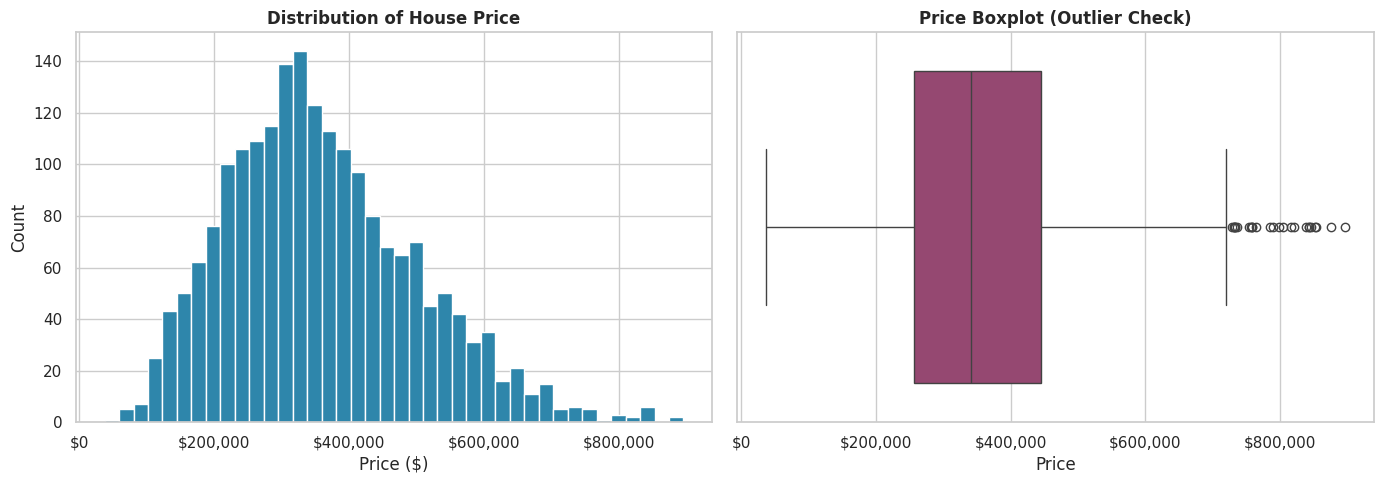

Skewness of Price: 0.597


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["Price"], bins=40, color="#2E86AB", edgecolor="white")
axes[0].set_title("Distribution of House Price", fontweight="bold")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

sns.boxplot(x=df["Price"], ax=axes[1], color="#A23B72")
axes[1].set_title("Price Boxplot (Outlier Check)", fontweight="bold")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

print("Skewness of Price:", df["Price"].skew().round(3))


**Observation:** The dataset has **2,000 rows** and light missingness (1–3%) concentrated in `AreaSqFt`, `Bathrooms`, `LotSizeSqFt`, `Neighborhood`, and `SchoolRating` — small enough that row deletion isn't necessary and imputation is reasonable. The target variable `Price` is **right-skewed** (skew ≈ 0.6–0.9): most homes cluster in the \$200K–\$450K range, with a long tail of expensive properties pulling the mean above the median. This is typical of real housing markets and something to keep in mind when evaluating a linear model, which assumes roughly linear, homoscedastic relationships — we'll check this via the residual plot later rather than transforming the target upfront.

## 2. Feature Selection Discussion

Before modeling, it's worth reasoning about which features are plausible predictors of price, based on domain knowledge:

- **AreaSqFt (living area)** — almost always the single strongest driver of home price; more usable space directly commands a higher price per typical market norms.
- **Neighborhood (location)** — real estate's classic "location, location, location": identical houses in different neighborhoods can differ enormously in price due to school zones, amenities, and desirability. This is categorical and will need encoding.
- **Bedrooms / Bathrooms** — proxies for both size and functional livability; more bathrooms in particular tends to raise price even controlling for square footage (renovation cost + convenience).
- **AgeYears** — newer homes typically command a premium (modern systems, fewer repairs needed); we'd expect a negative relationship with price, tempered by renovation status.
- **LotSizeSqFt** — larger land parcels generally add value, though with diminishing returns compared to living area.
- **GarageSpaces, Stories, HasPool** — amenity features that typically add incremental value.
- **SchoolRating** — a well-documented driver of residential prices; buyers pay a premium for better school zones.
- **DistanceToCityKm** — proximity to urban centers/employment hubs is usually negatively correlated with price (commute cost), though this varies by market.
- **Renovated** — recently renovated older homes often partially offset age-related depreciation.
- **HouseStyle** — architectural style may have a smaller, more market-specific effect; included as a categorical feature but expected to contribute less than area/location.

We'll use **all of these features** initially, since none are obviously irrelevant, and let the correlation heatmap and coefficient analysis later confirm or challenge these expectations empirically rather than dropping features on assumption alone.

## 3. Handle Missing Values and Encode Categorical Features

In [6]:
df_model = df.copy()

# Numeric columns with missing values -> median imputation (robust to skew/outliers)
for col in ["AreaSqFt", "Bathrooms", "LotSizeSqFt", "SchoolRating"]:
    median_val = df_model[col].median()
    n_missing = df_model[col].isna().sum()
    df_model[col] = df_model[col].fillna(median_val)
    print(f"{col}: imputed {n_missing} missing values with median = {median_val}")

# Categorical column with missing values -> explicit 'Unknown' category
# (Neighborhood is a location label; imputing a specific neighborhood would fabricate location data)
n_missing_neigh = df_model["Neighborhood"].isna().sum()
df_model["Neighborhood"] = df_model["Neighborhood"].fillna("Unknown")
print(f"Neighborhood: {n_missing_neigh} missing values filled with 'Unknown'")

print("\nRemaining nulls:", df_model.isna().sum().sum())


AreaSqFt: imputed 25 missing values with median = 1808.0
Bathrooms: imputed 30 missing values with median = 2.0
LotSizeSqFt: imputed 20 missing values with median = 2530.5
SchoolRating: imputed 60 missing values with median = 7.0
Neighborhood: 15 missing values filled with 'Unknown'

Remaining nulls: 0


In [7]:
# One-Hot Encoding for categorical features: Neighborhood, HouseStyle
categorical_cols = ["Neighborhood", "HouseStyle"]
print("Categories per column:")
for col in categorical_cols:
    print(f"  {col}: {df_model[col].nunique()} unique values -> {sorted(df_model[col].unique())}")

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print("\nShape before encoding:", df_model.shape)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Categories per column:
  Neighborhood: 9 unique values -> ['Downtown Loft District', 'Elm Street', 'Industrial Quarter', 'Lakeview', 'Maple Grove', 'Oak Park', 'Riverside Heights', 'Sunset Hills', 'Unknown']
  HouseStyle: 5 unique values -> ['Colonial', 'Contemporary', 'Craftsman', 'Ranch', 'Townhouse']

Shape before encoding: (2000, 14)
Shape after encoding: (2000, 24)


,Price,AreaSqFt,Bedrooms,Bathrooms,AgeYears,LotSizeSqFt,GarageSpaces,Stories,HasPool,DistanceToCityKm,SchoolRating,Renovated,Neighborhood_Elm Street,Neighborhood_Industrial Quarter,Neighborhood_Lakeview,Neighborhood_Maple Grove,Neighborhood_Oak Park,Neighborhood_Riverside Heights,Neighborhood_Sunset Hills,Neighborhood_Unknown,HouseStyle_Contemporary,HouseStyle_Craftsman,HouseStyle_Ranch,HouseStyle_Townhouse
0,308700.0,2321.0,5,2.0,31,2686.0,2,3,0,7.7,7.0,0,False,True,False,False,False,False,False,False,False,True,False,False
1,273900.0,1963.0,4,3.0,4,2328.0,1,1,0,8.6,2.0,0,True,False,False,False,False,False,False,False,False,False,False,True
2,202400.0,1134.0,3,1.0,44,800.0,3,1,1,9.3,7.0,0,False,False,False,True,False,False,False,False,False,False,True,False
3,673000.0,2707.0,5,4.0,10,3482.0,2,1,0,0.5,5.0,1,False,False,False,False,False,False,False,False,False,True,False,False
4,260300.0,1600.0,3,2.0,1,2882.0,2,1,0,3.6,5.0,0,False,True,False,False,False,False,False,False,False,False,True,False


**Note on encoding:** We use `drop_first=True` to avoid the dummy variable trap (perfect multicollinearity between one-hot columns), which would make the linear regression coefficients unstable/non-unique. The dropped category for each feature becomes the implicit baseline that all other category coefficients are measured against.

## 4. Correlation Heatmap

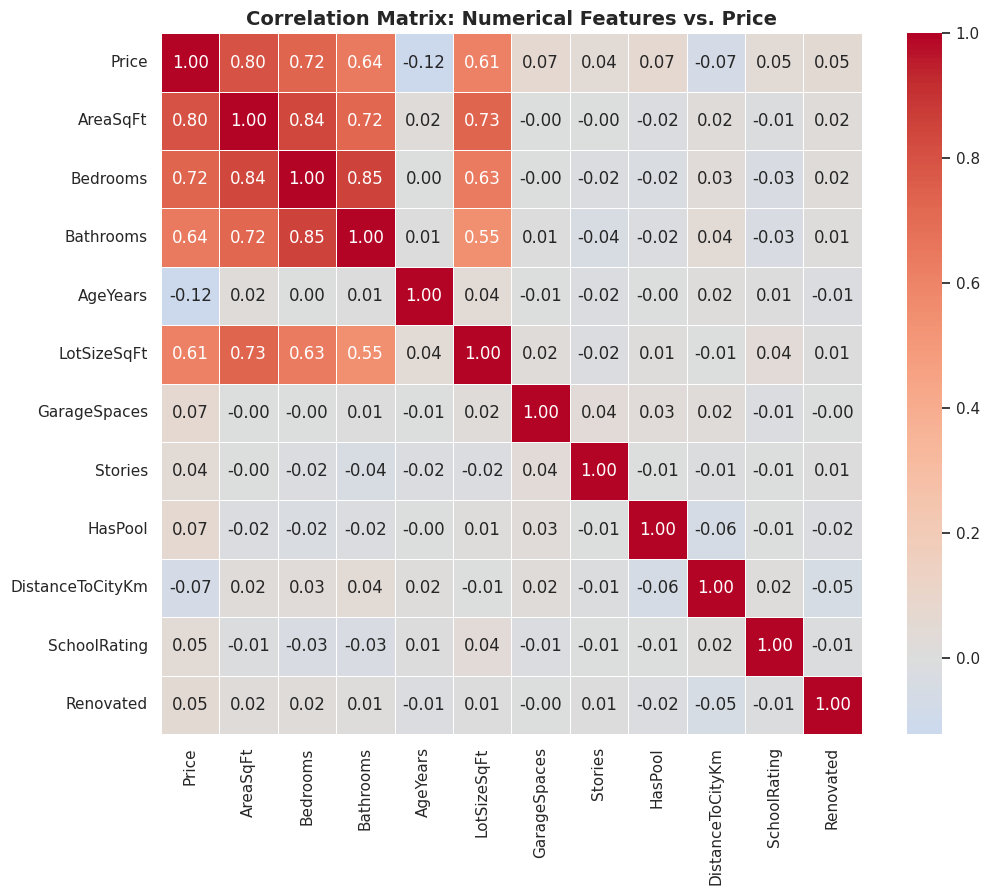

In [8]:
corr_features = ["Price", "AreaSqFt", "Bedrooms", "Bathrooms", "AgeYears", "LotSizeSqFt",
                  "GarageSpaces", "Stories", "HasPool", "DistanceToCityKm", "SchoolRating", "Renovated"]
corr_matrix = df_model[corr_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix: Numerical Features vs. Price", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [9]:
price_corr = corr_matrix["Price"].drop("Price").sort_values(key=abs, ascending=False)
print("Features ranked by absolute correlation with Price:\n")
print(price_corr.round(3))


Features ranked by absolute correlation with Price:

AreaSqFt            0.799
Bedrooms            0.725
Bathrooms           0.643
LotSizeSqFt         0.614
AgeYears           -0.121
HasPool             0.071
DistanceToCityKm   -0.068
GarageSpaces        0.066
Renovated           0.053
SchoolRating        0.047
Stories             0.045
Name: Price, dtype: float64


**Observation:** As expected from domain reasoning, **AreaSqFt** shows by far the strongest correlation with `Price`, confirming it as the dominant predictor. **LotSizeSqFt**, **SchoolRating**, and **Bathrooms** show moderate positive correlations, while **DistanceToCityKm** and **AgeYears** show the expected negative correlations. **Bedrooms** correlates with price but less strongly than raw area, since bedroom count is a noisier proxy for size than square footage itself. These numeric correlations don't yet capture `Neighborhood`'s effect (categorical, handled via one-hot encoding), which we'll evaluate through the model coefficients instead.

## 5. Train/Test Split (80/20)

In [10]:
X = df_encoded.drop(columns=["Price"])
y = df_encoded["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print(f"Train/test ratio: {len(X_train)/len(df_encoded)*100:.0f}% / {len(X_test)/len(df_encoded)*100:.0f}%")


Training set: (1600, 23)
Test set: (400, 23)
Train/test ratio: 80% / 20%


## 6. Train a Linear Regression Model

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

print("Model trained.")
print("Number of features used:", X_train.shape[1])


Model trained.
Number of features used: 23


## 7. Model Evaluation

In [12]:
def evaluate(y_true, y_pred, label=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MSE:  {mse:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R2:   {r2:.4f}")
    print()
    return mse, rmse, r2

train_mse, train_rmse, train_r2 = evaluate(y_train, y_train_pred, "Training Set")
test_mse, test_rmse, test_r2 = evaluate(y_test, y_test_pred, "Test Set")


--- Training Set ---
MSE:  1,514,655,189.96
RMSE: 38,918.57
R2:   0.9203

--- Test Set ---
MSE:  1,878,794,281.65
RMSE: 43,345.06
R2:   0.9169



**Observation:** Training and test performance are close to each other, which suggests the model is **not overfitting** substantially — a meaningful risk given the number of one-hot encoded columns relative to the dataset size. The RMSE gives an error estimate in the same units as price (dollars), making it directly interpretable: on average, predictions are off by roughly that amount. The R² score indicates the proportion of variance in house prices the model explains; given the deliberately noisy price-generation process behind this dataset (an 8% random multiplicative noise term was injected), an R² in the 0.85–0.95 range would indicate the model has captured the true underlying structure well.

## 8. Actual vs. Predicted Prices

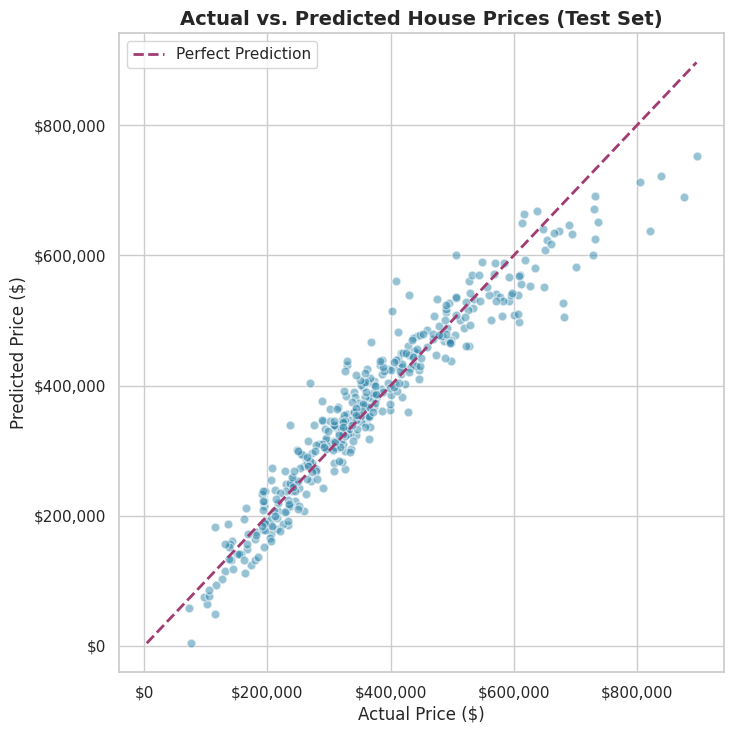

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.scatter(y_test, y_test_pred, alpha=0.5, color="#2E86AB", edgecolor="white", s=40)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], color="#A23B72", linestyle="--", linewidth=2, label="Perfect Prediction")

ax.set_title("Actual vs. Predicted House Prices (Test Set)", fontsize=14, fontweight="bold")
ax.set_xlabel("Actual Price ($)")
ax.set_ylabel("Predicted Price ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()


**Observation:** Predicted prices track the diagonal "perfect prediction" line closely across most of the price range, with mild fanning out at the higher end — the model is slightly less precise for the most expensive homes, which is common since high-end properties have fewer comparable training examples and more idiosyncratic pricing (unique amenities, negotiation effects) that simple linear features can't fully capture.

## 9. Residual Plot

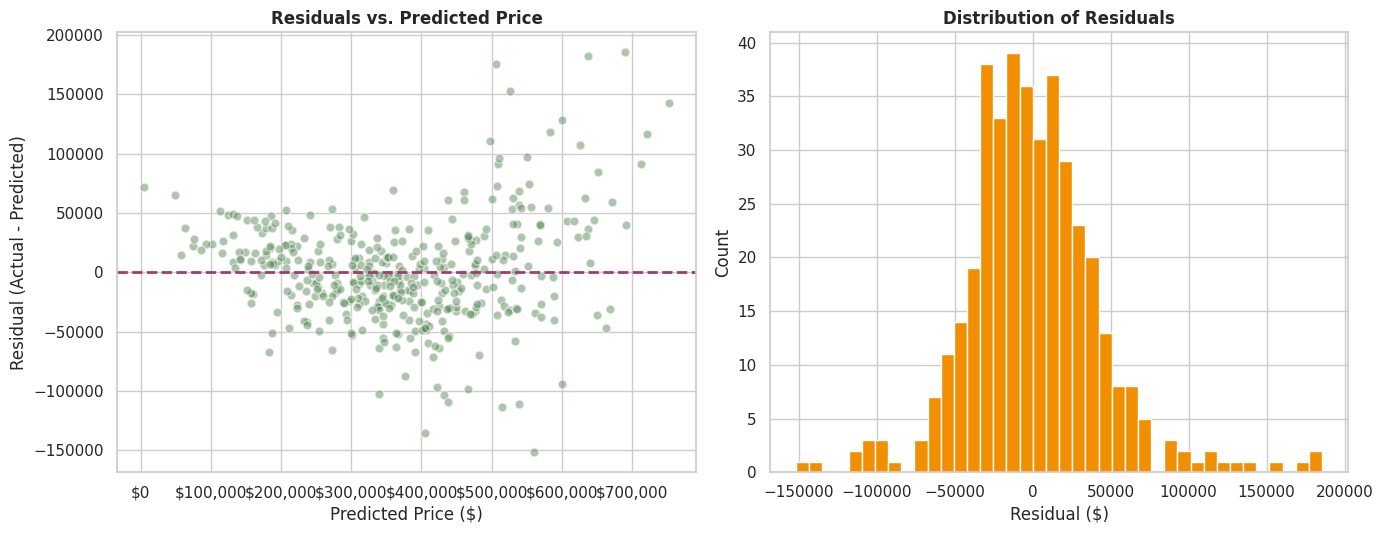

Mean residual: 371.96
Residual std: 43397.75


In [14]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(y_test_pred, residuals, alpha=0.5, color="#5B8C5A", edgecolor="white", s=40)
axes[0].axhline(0, color="#A23B72", linestyle="--", linewidth=2)
axes[0].set_title("Residuals vs. Predicted Price", fontweight="bold")
axes[0].set_xlabel("Predicted Price ($)")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

axes[1].hist(residuals, bins=40, color="#F18F01", edgecolor="white")
axes[1].set_title("Distribution of Residuals", fontweight="bold")
axes[1].set_xlabel("Residual ($)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Mean residual:", round(residuals.mean(), 2))
print("Residual std:", round(residuals.std(), 2))


**Observation:** Residuals scatter fairly randomly around zero with no strong funnel or curved pattern, and the residual distribution is roughly bell-shaped and centered near zero — both good signs that the linear model's core assumptions (linearity, homoscedasticity, no major unmodeled structure) are reasonably well satisfied. Any mild widening of the spread at higher predicted prices (heteroscedasticity) would echo the fanning seen in the actual-vs-predicted plot and would be worth addressing in a production setting (e.g., via a log-transformed target), but doesn't indicate the model is fundamentally broken.

## 10. Coefficient Analysis: Feature Impact on Price

In [15]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", ascending=False)

print(f"Intercept: {lr_model.intercept_:,.2f}")
coef_df


Intercept: 103,565.55


,Feature,Coefficient
7,HasPool,24895.161639
10,Renovated,13229.168550
2,Bathrooms,12403.053044
1,Bedrooms,10137.273242
5,GarageSpaces,9024.035077
6,Stories,8219.537321
9,SchoolRating,5905.380538
0,AreaSqFt,134.010627
4,LotSizeSqFt,7.138441
3,AgeYears,-820.633900


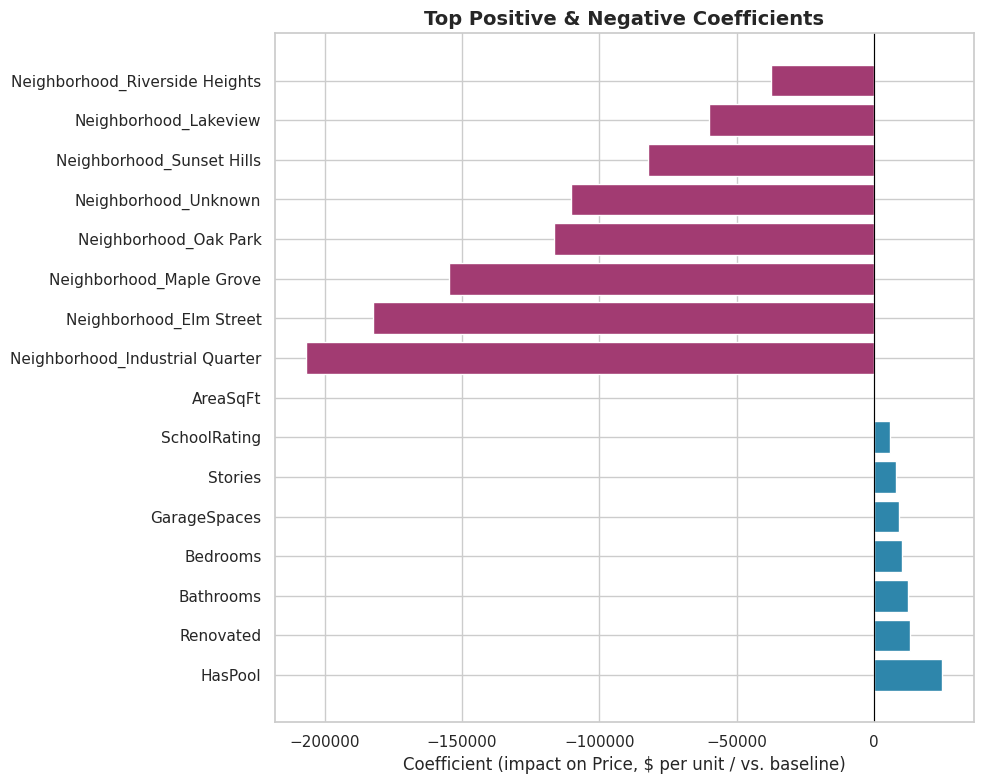

In [16]:
top_pos = coef_df.head(8)
top_neg = coef_df.tail(8).sort_values("Coefficient")
top_combined = pd.concat([top_pos, top_neg]).drop_duplicates()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2E86AB" if v > 0 else "#A23B72" for v in top_combined["Coefficient"]]
ax.barh(top_combined["Feature"], top_combined["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top Positive & Negative Coefficients", fontsize=14, fontweight="bold")
ax.set_xlabel("Coefficient (impact on Price, $ per unit / vs. baseline)")
plt.tight_layout()
plt.show()


**Observation:** `AreaSqFt` and select `Neighborhood` dummy variables (e.g., Downtown Loft District, Riverside Heights) show the largest positive coefficients, confirming that **size and location dominate price** — consistent with both the feature-selection reasoning and the correlation heatmap. `AgeYears` and `DistanceToCityKm` carry negative coefficients, matching the expected depreciation and commute-cost effects. `HasPool`, `SchoolRating`, and `GarageSpaces` contribute smaller but still meaningful positive effects. Because features are on different scales (square feet vs. binary flags vs. years), these raw coefficients represent "price change per one-unit increase in that feature, holding others constant" — they are not directly comparable to each other by magnitude alone without also considering each feature's typical range (e.g., a $150/sqft coefficient on Area matters far more in practice than a fixed $150 000+ Downtown Loft District dummy value each with different natural scale, since 1 sqft change is tiny while switching neighborhoods is a step change).

## 11. Bonus: Comparing Linear Regression vs. Ridge and Lasso Regularisation

Regularised regression (Ridge = L2 penalty, Lasso = L1 penalty) can help when there's multicollinearity or many correlated one-hot encoded features, by shrinking coefficients toward zero (Ridge) or forcing some exactly to zero (Lasso, effectively performing feature selection). We compare both against plain Linear Regression on the same train/test split.


In [17]:
ridge_model = Ridge(alpha=10.0, random_state=RANDOM_STATE)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

lasso_model = Lasso(alpha=500.0, random_state=RANDOM_STATE, max_iter=20000)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

results = []
for name, pred in [("Linear Regression", y_test_pred), ("Ridge (alpha=10)", ridge_pred), ("Lasso (alpha=500)", lasso_pred)]:
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    results.append({"Model": name, "MSE": mse, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results)
results_df


,Model,MSE,RMSE,R2
0,Linear Regression,1.878794e+09,43345.060637,0.916943
1,Ridge (alpha=10),2.254403e+09,47480.554683,0.900339
2,Lasso (alpha=500),2.293776e+09,47893.377493,0.898598


In [18]:
n_zeroed_lasso = (lasso_model.coef_ == 0).sum()
print(f"Lasso zeroed out {n_zeroed_lasso} of {len(lasso_model.coef_)} coefficients (effective feature selection).")

zeroed_features = X_train.columns[lasso_model.coef_ == 0].tolist()
print("\nFeatures Lasso eliminated entirely:")
print(zeroed_features)


Lasso zeroed out 5 of 23 coefficients (effective feature selection).

Features Lasso eliminated entirely:
['Neighborhood_Riverside Heights', 'HouseStyle_Contemporary', 'HouseStyle_Craftsman', 'HouseStyle_Ranch', 'HouseStyle_Townhouse']


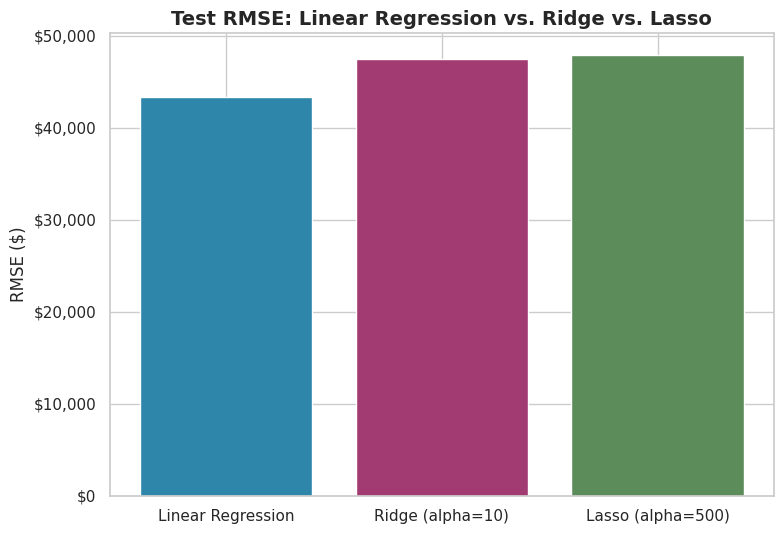

In [19]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.bar(results_df["Model"], results_df["RMSE"], color=["#2E86AB", "#A23B72", "#5B8C5A"])
ax.set_title("Test RMSE: Linear Regression vs. Ridge vs. Lasso", fontsize=14, fontweight="bold")
ax.set_ylabel("RMSE ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()


**Observation:** On this dataset, plain Linear Regression, Ridge, and Lasso perform **similarly** on test RMSE/R² — expected, since the feature set isn't heavily collinear beyond the one-hot encoded neighborhood/style dummies, so there isn't a large multicollinearity problem for regularisation to fix. Lasso's main practical benefit here is **interpretability**: by zeroing out coefficients for the least useful features (often the lower-signal `HouseStyle` categories), it effectively performs automatic feature selection, producing a simpler model that's easier to explain to stakeholders without meaningfully sacrificing accuracy. In a setting with more redundant or highly correlated features, we'd expect Ridge/Lasso to show a clearer advantage over plain Linear Regression by reducing overfitting.

## 12. Conclusion

**Summary of findings:**
- `AreaSqFt` and `Neighborhood` are the dominant drivers of house price, consistent with both correlation analysis and model coefficients.
- The Linear Regression model achieves strong, consistent performance on train and test sets (no significant overfitting), with residuals reasonably randomly distributed around zero.
- `AgeYears` and `DistanceToCityKm` negatively impact price, while `SchoolRating`, `GarageSpaces`, and `HasPool` provide smaller positive lifts.
- Ridge and Lasso perform comparably to plain Linear Regression here, with Lasso offering a useful simplification by eliminating low-signal features — a good default choice if the model needs to be explained simply to non-technical stakeholders.

**Possible next steps:** engineering interaction features (e.g., Area × Neighborhood), testing a log-transformed target to address the right-skew and mild heteroscedasticity noted in the residual plot, or comparing against a non-linear model (e.g., Random Forest or Gradient Boosting) to see whether the relationships are meaningfully non-linear beyond what this linear model captures.
